# Projeto 3 - Análise e Previsão de Aluguel

Nesse projeto será preciso fazer uma série de análise de dados para responder algumas perguntas e criar um modelo preditivo.

## Dicionário de dados

* __id__ -> Identificador do imóvel
* __category__ -> Categoria do imóvel
* __title__ -> Titulo do anuncio
* __body__ -> Descrição do anúncio
* __amenities__ -> Comodidade do imóvel
* __bathrooms__ -> Quantidade de banheiros
* __bedrooms__ -> Quantidade de quartos
* __currency__ -> Moeda
* __fee__ -> Valor de taxas extras
* __has_photo__ -> Se o imóvel possui foto
* __pets_allowed__ -> Se o imóvel permite animais
* __price__ -> Valor do aluguel mensal (Variável _TARGET_)
* __price_display__ -> Valor do aluguel mensal exibido
* __price_type__ -> Tipo de aluguel
* __square_feet__ -> Tamanho do imóvel (Para converter para metros quadrados basta dividir por 10.76).
* __address__ -> Endereço do imóvel
* __cityname__ -> Cidade do imóvel
* __state__ -> Estado do imóvel
* __latitude__ -> Latitude do imóvel
* __longitude__ -> Longitude do imóvel
* __source__ -> Fonte / Tipo de imobiliária que o imóvel está disponível para alugar.
* __time__ -> Hora que o anúncio foi inserido

### 1° Passo - Definição do Problema de Negócio / Objetivo

1. Identificar qual imobiliária possui a maior quantidade de imóveis para alugar.
2. Identificar qual estado possui a maior quantidade de imóveis para alugar.
3. Identificar a média de dias que os imóveis estão disponíveis para alugar e também os dias mínimos e máximos.
4. Identificar o valor médio do aluguel do imóvel por estado
5. Identificar quantos imóveis tem piscina e quantos tem academia

> Criar um modelo preditivo para gerar previsões dos valores de aluguel, demonstrando que o mesmo foi avaliado para garantir que não esteja gerando **overfitting**.

### 2° Passo - Coleta de Dados e Importação de Pacotes

In [1]:
#!pip install folium

In [2]:
import pandas as pd
import numpy as np
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Produção de gráficos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn import neighbors

# Separação de treino e teste
from sklearn.model_selection import train_test_split

# Algoritmos para criar modelos preditivos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from datetime import datetime

# Adicionar marcadores no mapa
import folium
from folium import plugins

# Pré-processadores / transformadores
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Validar a performance do modelo
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Padronização / Normalização dos dados
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import warnings
import os
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=Warning)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
# Carregando os dados

FILE_NAME = 'apartments_for_rent_classified_100K.csv'

if os.path.exists(FILE_NAME):
    try:
        components = np.array([os.getcwd(), FILE_NAME])
        path = os.path.join(*np.concatenate(components.reshape(-1, 1)))
    except Exception as e:
        raise FileNotFoundError(f'Error loading the file -> {e}')

df = pd.read_csv(
    path,
    encoding='ISO-8859-1',
    na_filter=True,
    verbose=0,
    sep=';',
    low_memory=False
)

df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,"$2,195",Monthly,542.0,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,"$1,250",Monthly,1500.0,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,NaN,1395.0,"$1,395",Monthly,1650.0,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1.577360e+09
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1600.0,"$1,600",Monthly,820.0,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1.577360e+09
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",975.0,$975,Monthly,624.0,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1.577360e+09


### 3° Passo - Análise Exploratória / Análise de Dados

In [4]:
df.shape

(93283, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93283 entries, 0 to 93282
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             93283 non-null  int64  
 1   category       93283 non-null  object 
 2   title          93283 non-null  object 
 3   body           93283 non-null  object 
 4   amenities      77702 non-null  object 
 5   bathrooms      93219 non-null  float64
 6   bedrooms       93164 non-null  float64
 7   currency       93282 non-null  object 
 8   fee            93282 non-null  object 
 9   has_photo      93282 non-null  object 
 10  pets_allowed   36547 non-null  object 
 11  price          93281 non-null  float64
 12  price_display  93281 non-null  object 
 13  price_type     93282 non-null  object 
 14  square_feet    93282 non-null  float64
 15  address        7943 non-null   object 
 16  cityname       92980 non-null  object 
 17  state          92980 non-null  object 
 18  latitu

In [6]:
# Verificando se há valores nulos no DataFrame
df.isna().sum()

id                   0
category             0
title                0
body                 0
amenities        15581
bathrooms           64
bedrooms           119
currency             1
fee                  1
has_photo            1
pets_allowed     56736
price                2
price_display        2
price_type           1
square_feet          1
address          85340
cityname           303
state              303
latitude            26
longitude           26
source               1
time                 1
dtype: int64

In [7]:
# Analisar os vlaores únicos de cada variável
unique_vals = []
for c in df.columns[0:23]:
    print(c, ':', df[c].nunique())

id : 93199
category : 7
title : 55210
body : 88619
amenities : 9285
bathrooms : 16
bedrooms : 10
currency : 1
fee : 2
has_photo : 3
pets_allowed : 4
price : 3618
price_display : 3649
price_type : 3
square_feet : 2492
address : 7771
cityname : 2886
state : 51
latitude : 6890
longitude : 6938
source : 25
time : 69631


In [8]:
# Visualizando medidas estatísticas

df.describe()

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,9.328300e+04,93219.000000,93164.000000,93281.000000,93282.000000,93257.000000,93257.000000,9.328200e+04
mean,5.374055e+09,1.443976,1.728393,1527.404788,955.763084,37.048661,-91.592452,1.560692e+09
std,1.800943e+08,0.546877,0.749234,907.423666,420.746911,4.564219,15.888387,1.064718e+07
min,5.121046e+09,1.000000,0.000000,100.000000,101.000000,19.666000,-159.369800,1.544174e+09
25%,5.198170e+09,1.000000,1.000000,1015.000000,728.000000,33.771800,-104.828200,1.550840e+09
50%,5.508732e+09,1.000000,2.000000,1355.000000,900.000000,37.436700,-84.538200,1.568748e+09
75%,5.509028e+09,2.000000,2.000000,1795.000000,1115.000000,39.964300,-77.494800,1.568769e+09
max,5.669439e+09,9.000000,9.000000,52500.000000,50000.000000,61.594000,-68.778800,1.577391e+09


In [9]:
# Agrupamento para ver o total de observações para cada estado

df.groupby(['state'], observed=False).size().sort_values(ascending=1)

state
DE        7
WV        9
WY       14
NM       24
HI       29
ME       32
AK       53
MS       56
SD       77
ID       77
MT       87
RI       90
DC       93
VT      125
OR      248
AL      271
IA      301
WI      375
IN      376
MN      444
NY      475
CT      509
MI      545
AR      598
UT      638
SC      644
NH      735
ND      743
TN      813
IL      852
KS      903
OK      934
PA      984
KY      995
NE     1020
MO     1081
LA     1345
AZ     2214
WA     2590
NV     2815
GA     4290
NJ     4445
OH     4905
MA     4917
MD     5043
FL     5194
NC     5763
CO     6290
VA     8036
CA     9473
TX    10403
dtype: int64

In [10]:
# Agrupamento para ver o total de observações para cada tipo de imobiliária

df.groupby(['source'], observed=False).size().sort_values(ascending=1)

source
AgentWebsite             1
Apartable                1
Z57                      1
FreeAdsTime              1
Real Estate Shows        1
HousesForRent            1
Real Estate Agent        1
Seattle Rentals          2
rentbits                 5
Nest Seekers             5
vFlyer                   5
Home Rentals             8
Claz                     8
RentFeeder              12
RENTOCULAR              18
SpreadMyAd              22
Listanza                29
RENTCafé                41
BostonApartments        94
tenantcloud            124
RealRentals            268
GoSection8             437
ListedBuy              571
RentLingo             6924
RentDigs.com         84702
dtype: int64

In [11]:
# Agrupamento para ver o total de observações para cada tipo de aluguel

df.groupby(['price_type'], observed=False).size().sort_values(ascending=1)

price_type
Monthly|Weekly        1
Weekly                3
Monthly           93278
dtype: int64

In [12]:
# Agrupamento para ver o total de observações para cada "taxa"

df.groupby(['fee'], observed=False).size().sort_values(ascending=1)

fee
Yes      201
No     93081
dtype: int64

In [13]:
# Agrupamento para ver o total de observações para cada "categoria"

df.groupby(['category'], observed=False).size().sort_values(ascending=1)

category
housing/rent/other                    1
housing/rent/condo                    3
housing/rent/home                     4
housing/rent/short_term               4
housing/rent                          7
housing/rent/commercial/retail       42
housing/rent/apartment            93222
dtype: int64

In [14]:
# Agrupamento para ver o total de observações para cada "permite pets"

df.groupby(['pets_allowed'], observed=False).size().sort_values(ascending=1)

pets_allowed
Cats,Dogs,None        1
Dogs                127
Cats               1744
Cats,Dogs         34675
dtype: int64

In [15]:
# Agrupamento para ver o total de observações para cada "comodidade"

df.groupby(['amenities'], observed=False).size().sort_values(ascending=0)[0:10]

amenities
Parking               5922
Parking,Storage       2014
Gym,Pool              1742
Pool                  1411
Gym,Parking,Pool      1116
Parking,Pool           829
Washer Dryer           758
Patio/Deck             738
Clubhouse,Gym,Pool     721
Gym                    674
dtype: int64

In [16]:
# Agrupamento para ver o total de observações para cada "aluguel"

df.groupby(['price'], observed=False).size().sort_values(ascending=0).head(10)

price
1350.0    544
850.0     509
1200.0    500
1100.0    500
950.0     496
1250.0    488
1500.0    481
1450.0    476
1400.0    457
1300.0    440
dtype: int64

In [17]:
# Segundo a análise, foi constatado que alguns atributos possuem um valor máximo bem elevado, como
# por exemplo o valor de aluguel.
# Nesse caso iremos identificar em que o valor do aluguel é superior a 30.000

df.loc[df['price'] > 30000].head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
6863,5666447277,housing/rent/apartment,Studio apartment for rent,Barstow It's 14/18ft. studio apartment furnish...,"AC,Cable or Satellite,Internet Access,Patio/De...",1.0,0.0,USD,No,Thumbnail,NaN,52500.0,"$52,500",Monthly,1418.0,1101 Pueblo Drive,Barstow,CA,34.8870,-117.0350,RentDigs.com,1.577186e+09
17131,5508899537,housing/rent/apartment,Four BR - ready to move in.,"Stunning, recently renovated home in the with ...",Parking,4.0,4.0,USD,No,Thumbnail,NaN,35000.0,"$35,000",Monthly,2269.0,NaN,West Hollywood,CA,34.0939,-118.3801,RentDigs.com,1.568760e+09
28037,5508903100,housing/rent/apartment,Pet Friendly 6+5 Apartment in West Hollywood,This state of the art and renovated showplace ...,"Dishwasher,Elevator,Fireplace,Parking,Patio/De...",5.0,7.0,USD,No,No,NaN,35000.0,"$35,000",Monthly,5586.0,NaN,West Hollywood,CA,34.0939,-118.3801,RentDigs.com,1.568761e+09
38473,5508885857,housing/rent/apartment,"Average Rent $32,000 a month - That's a STEAL....",This spectacular estate boasts four story of l...,"Elevator,Fireplace,Parking,Patio/Deck,TV",9.0,6.0,USD,No,Yes,NaN,32000.0,"$32,000",Monthly,5055.0,NaN,Los Angeles,CA,34.1176,-118.3327,RentDigs.com,1.568760e+09
40715,5508903015,housing/rent/apartment,"Stunning estate in the heart of /Sunset, just ...","Newly complete furnished, available for long o...","Elevator,Hot Tub,Patio/Deck,Pool",7.5,6.0,USD,No,No,NaN,35000.0,"$35,000",Monthly,6366.0,NaN,West Hollywood,CA,34.0939,-118.3801,RentDigs.com,1.568761e+09


In [18]:
# Verificar quantos casos de imóveis que possuem valor de aluguel acima de 10.000

df_qty = df.loc[df['price'] > 10000]
print(f'Quantidade de observações: {df_qty.shape[0]}')

Quantidade de observações: 67


In [19]:
# Carregando variaveis para plot
NUMERIC_DTYPES = [np.int64, np.float64]
MAX_COLS = 23

num_vars: list[str] = (
    df.iloc[:, :MAX_COLS]
    .select_dtypes(include=NUMERIC_DTYPES)
    .columns
    .tolist()
)

In [20]:
# Filtrando apenas as colunas necessárias da lista

COLS_TO_EXCLUDE = frozenset({'id', 'latitude', 'longitude', 'time'})

#def filter_columns(cols: list[str]) -> list[str]:
 #   return [c for c in cols if c not in COLS_TO_EXCLUDE]

#num_vars = filter_columns(num_vars)

df_filtered = df[
    list(
        filter(
            lambda c: c not in COLS_TO_EXCLUDE,
            df.iloc[:, :23]
              .apply(lambda col: np.issubdtype(col.dtype, np.number))
              .pipe(lambda mask: df.columns[:23][mask])
        )
    )
]

In [21]:
num_vars = df_filtered.columns.tolist()

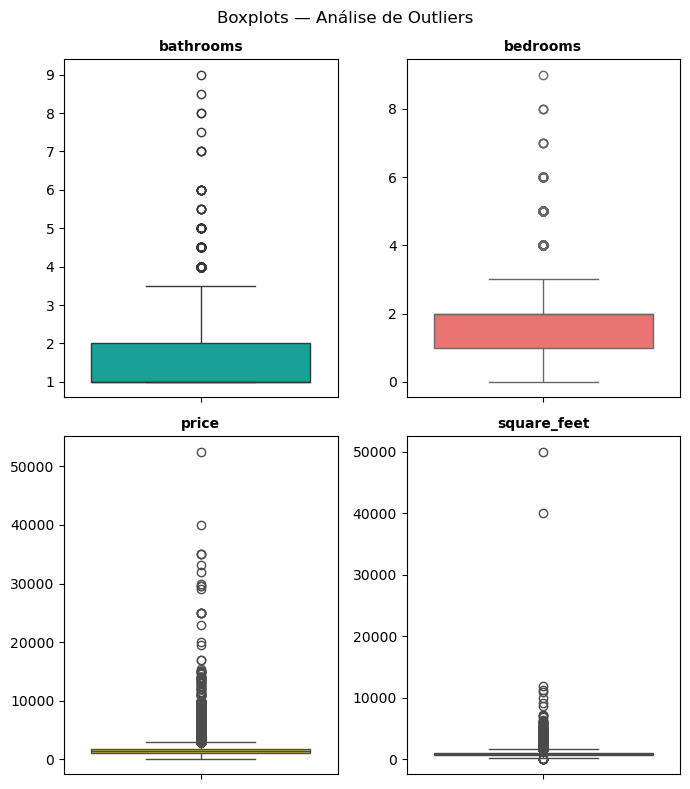

In [22]:
# Plotagem do boxplot para identificar "outliers" das variáveis armazenadas na lista
import math

COLORS = ['#01B8AA', '#FD625E', '#F2C80F', '#4626cf']
n = len(num_vars)
ncols = 2
nrows = math.ceil(n / ncols)

plt.rcParams['figure.figsize'] = [7, nrows * 4]
plt.rcParams['figure.autolayout'] = True

fig, axes = plt.subplots(2, 2)

for i, (v, ax) in enumerate(zip(num_vars, axes.flatten())):
    sns.boxplot(
        df[v], 
        color=COLORS[i % len(COLORS)], 
        ax=ax, 
        orient='v', 
        saturation=.75
    )

    ax.set_title(v, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('Boxplots — Análise de Outliers', fontsize=12, fontweight='medium')
plt.show()

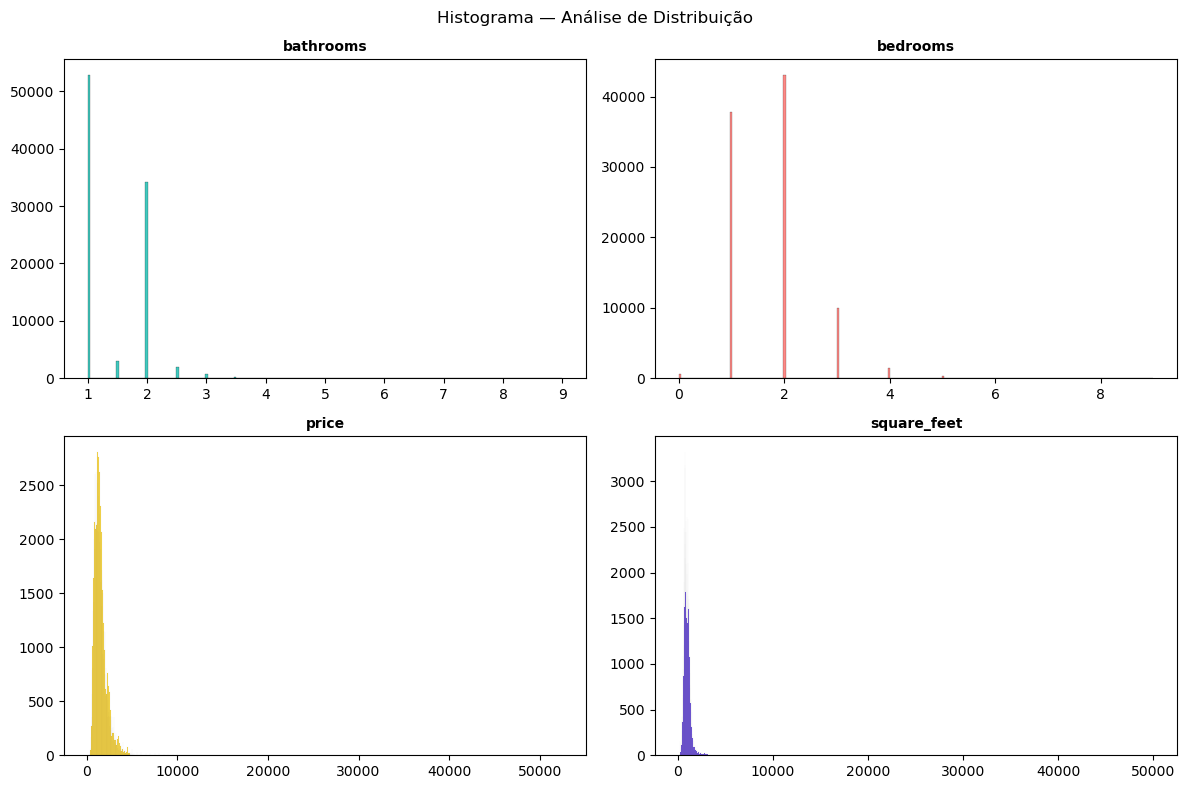

In [23]:
# Plotagem do histograma para analisar a distribuição das variaveis
import math

COLORS = ['#01B8AA', '#FD625E', '#F2C80F', '#4626cf']
n = len(num_vars)
ncols = 2
nrows = math.ceil(n / ncols)

plt.rcParams['figure.figsize'] = [12, nrows * 4]
plt.rcParams['figure.autolayout'] = True

fig, axes = plt.subplots(2, 2)

for i, (v, ax) in enumerate(zip(num_vars, axes.flatten())):
    sns.histplot(
        df[v], 
        color=COLORS[i % len(COLORS)], 
        legend=0, 
        multiple='layer', 
        ax=ax
    )

    ax.set_title(v, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('Histograma — Análise de Distribuição', fontsize=12, fontweight='regular')
plt.show()

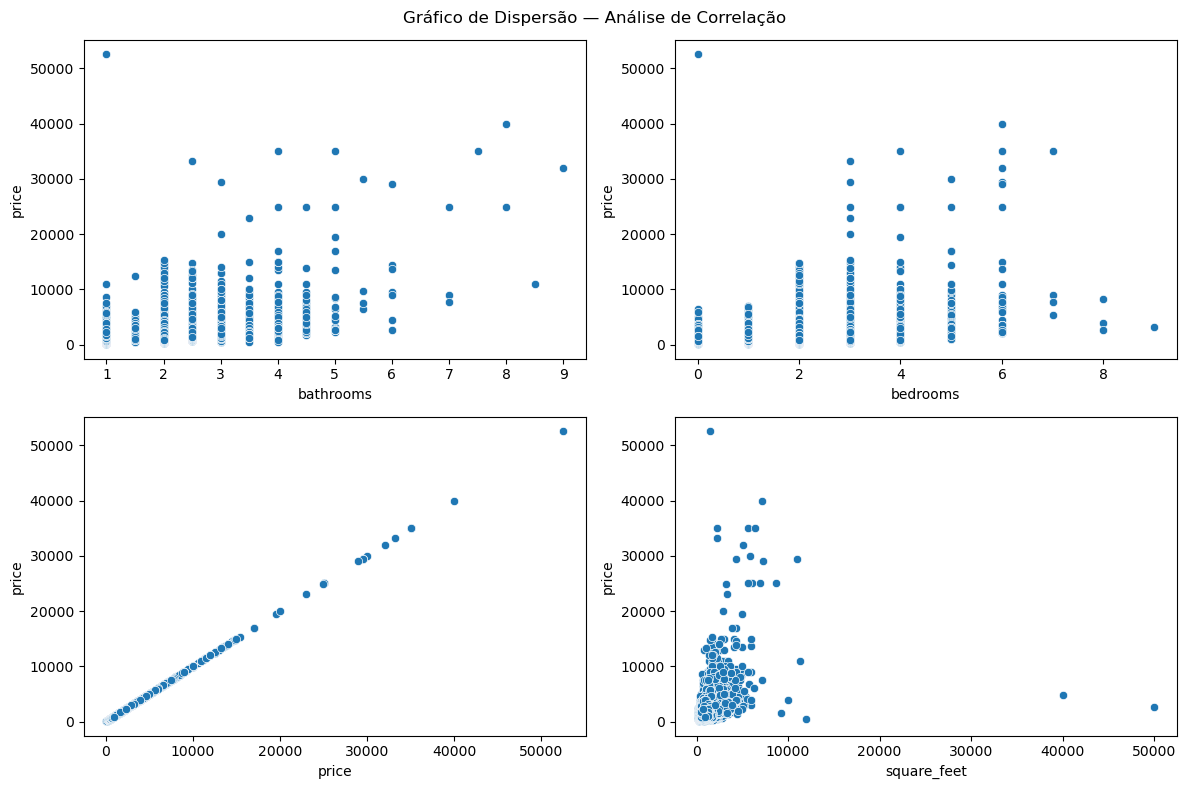

In [24]:
# Plotagem do scatterplot para analisar a correlação de cada variavel com o valor do aluguel
import math

n = len(num_vars)
ncols = 2
nrows = math.ceil(n / ncols)

plt.rcParams['figure.figsize'] = [12, nrows * 4]
plt.rcParams['figure.autolayout'] = True

fig, axes = plt.subplots(2, 2)

for i, (v, ax) in enumerate(zip(num_vars, axes.flatten())):
    sns.scatterplot(
        x=df[v], 
        y=df['price'], 
        markers='o', 
        ax=ax
    )

fig.suptitle('Gráfico de Dispersão — Análise de Correlação', fontsize=12, fontweight='regular')
plt.show()

In [25]:
# Carregar variáveis categóricas para OneHotEncoding e OrdinalEncoding

cat_vars = [cname for cname in df.select_dtypes(include=['object', 'category']).columns.ravel()]

In [26]:
# Filtrando apenas as variaveis que serão necessárias para o pré-processamento

cat_vars = ['pets_allowed', 'state', 'category', 'fee', 'has_photo', 'price_type', 'source']
cat_vars

['pets_allowed',
 'state',
 'category',
 'fee',
 'has_photo',
 'price_type',
 'source']

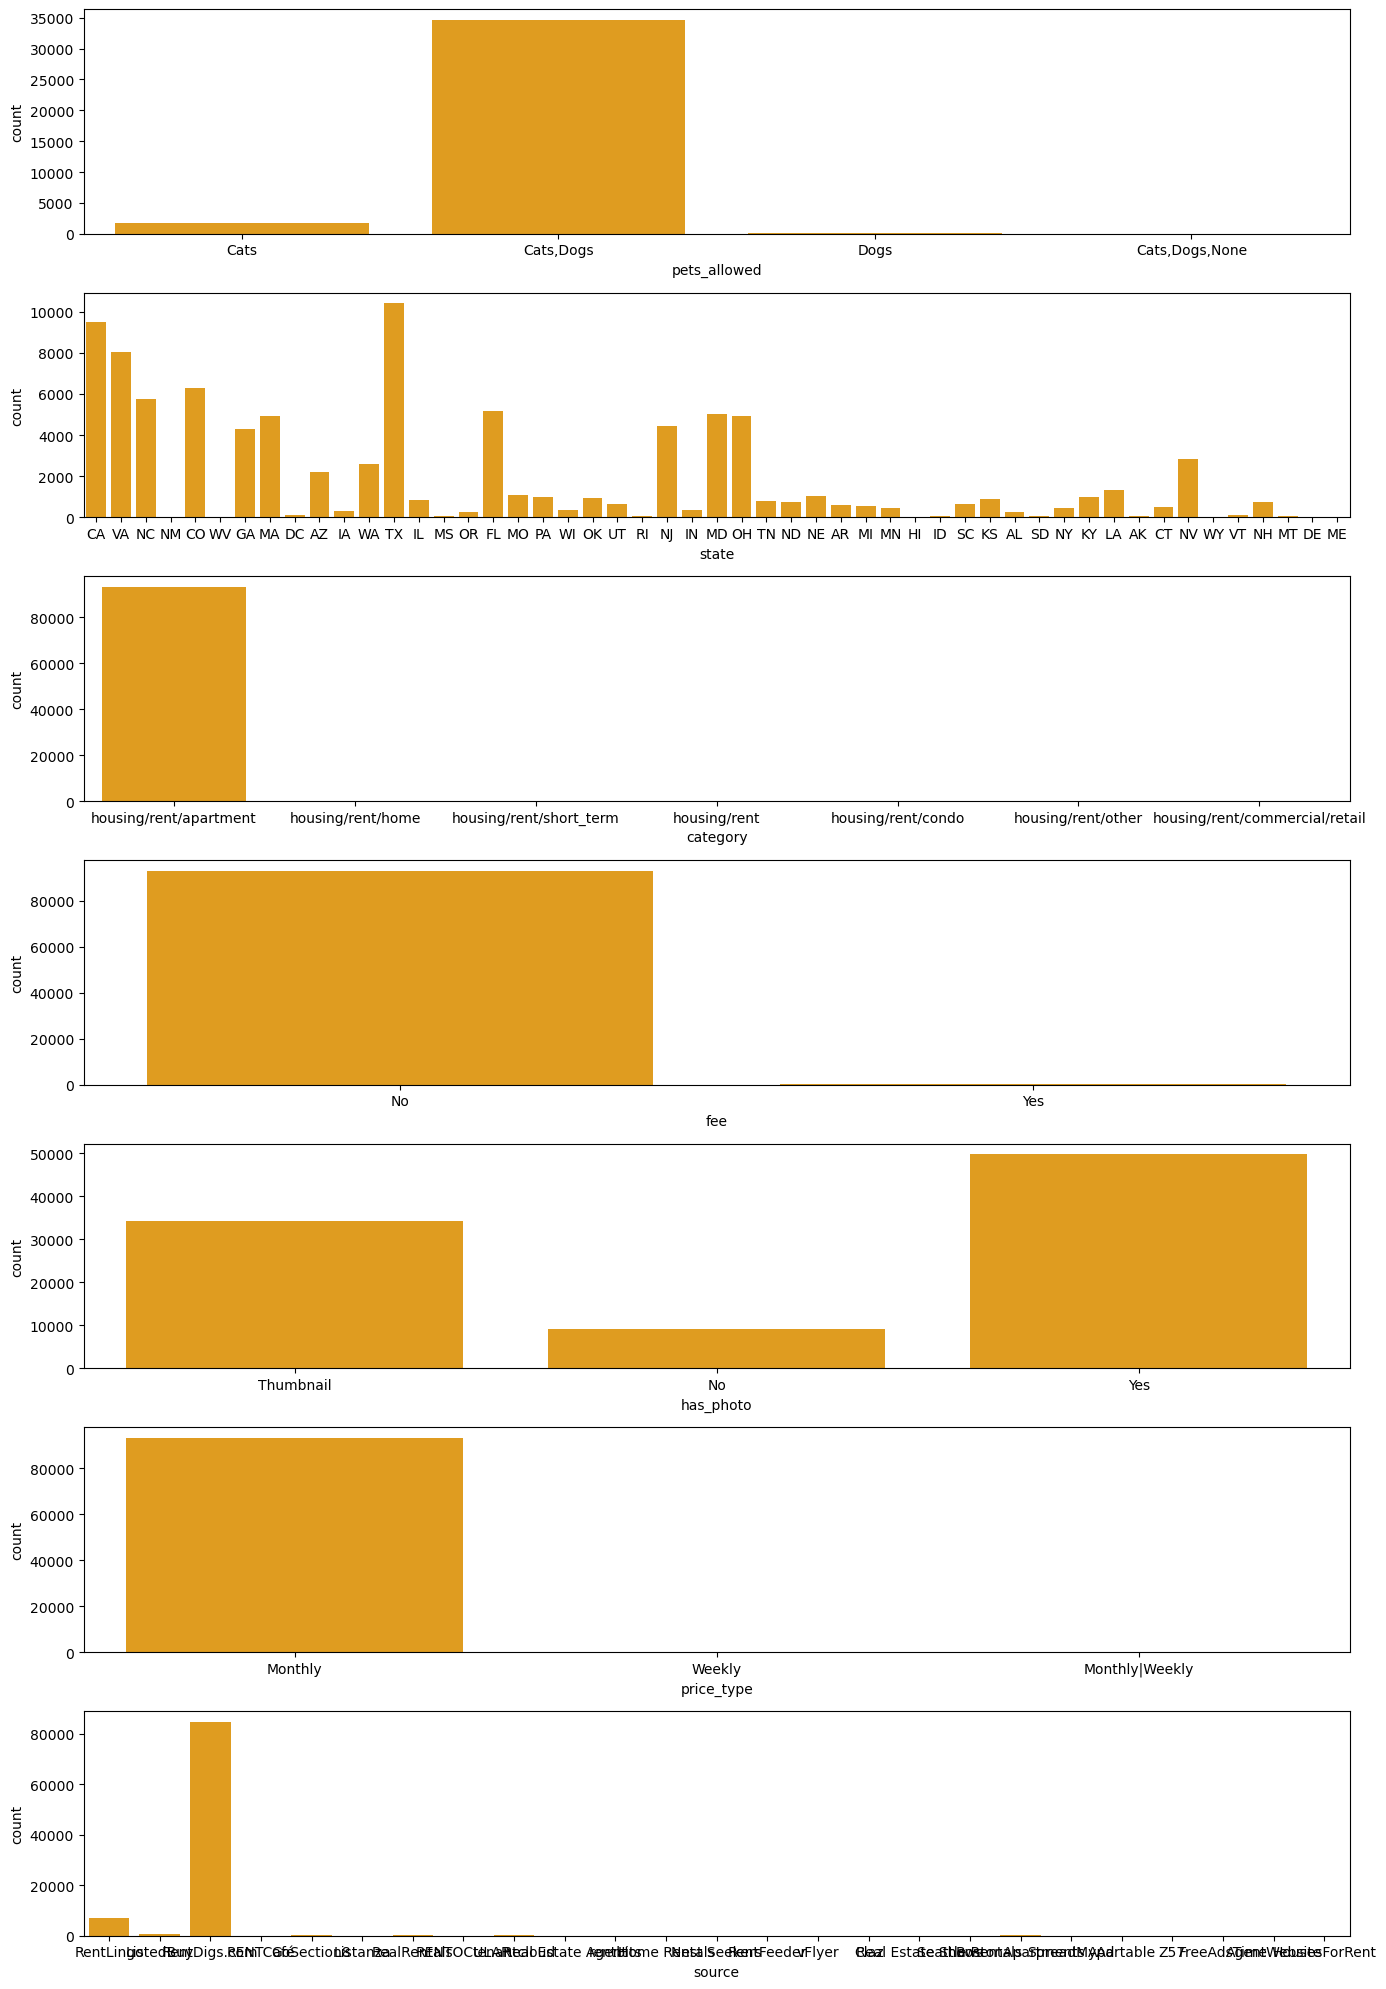

In [27]:
plt.rcParams['figure.figsize'] = [14, 20]
plt.rcParams['figure.autolayout'] = True

fig, axes = plt.subplots(7, 1)

for v, ax in zip(cat_vars, axes.flatten()):
    sns.countplot(x=df[v], color='orange', ax=ax)

    ax.set_xlabel(f'{v}')

plt.show()

In [28]:
# Analisando o tipo de "Imobiliaria" de outra forma
df_source = df.groupby(['source']).size().reset_index()
df_source.columns = ['source', 'count'].copy()
df_source = df_source.sort_values(by=['count'], ascending=False)
df_source

,source,count
16,RentDigs.com,84702
18,RentLingo,6924
9,ListedBuy,571
5,GoSection8,437
15,RealRentals,268
23,tenantcloud,124
2,BostonApartments,94
11,RENTCafé,41
8,Listanza,29
20,SpreadMyAd,22


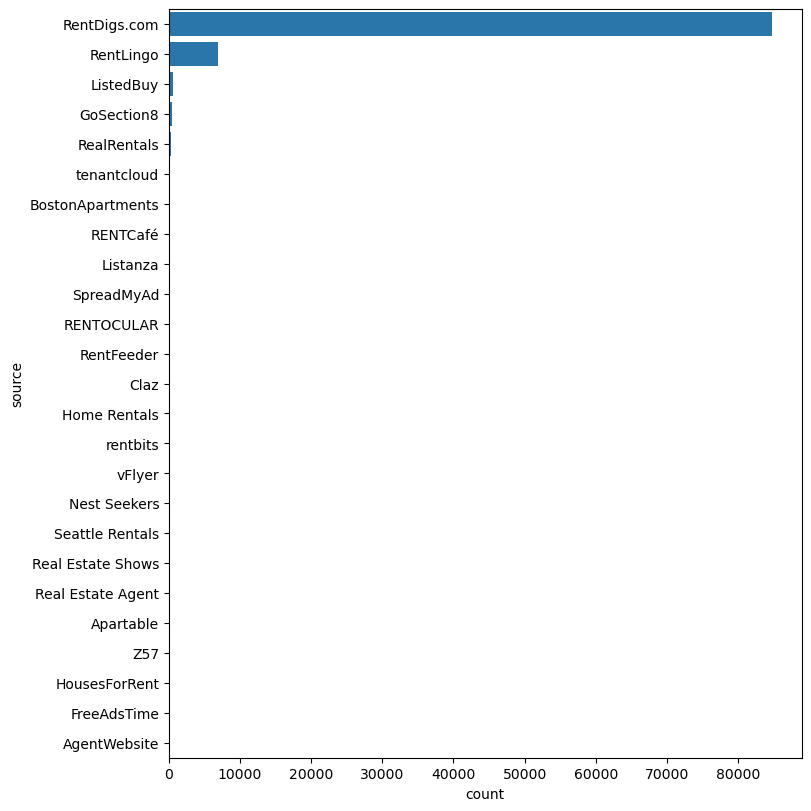

In [29]:
# Gráfico de barras para visualizar a quantidade de imóveis por imobiliária

fig = plt.figure(figsize=(8, 8), layout='constrained')
sns.barplot(
    data=df_source,
    x='count',
    y='source',
    orient='h',
    saturation=.85
)

# Anotações de valor em cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=4, fontsize=10)

ax.set_title(f'Imobiliaria', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Quantidade', fontsize=11)
ax.set_ylabel('Imobiliaria', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)  # visual mais limpo

plt.show()

In [30]:
# Analisando os imoveis distribuidos através de um mapa com marcadores

df_location = df.copy()
df_location = df_location.dropna(subset=['latitude', 'longitude'])
df_location['lat_lon'] = df_location['latitude'].astype(str) + ' - ' + df['longitude'].astype(str)
df_location = df_location.groupby(['latitude', 'longitude', 'lat_lon']).size().reset_index()
df_location.columns = ['latitude', 'longitude', 'lat_lon', 'count']
df_location = df_location.loc[df_location['count'] > 10]

latitude = df_location.latitude.values
longitude = df_location.longitude.values

# Mepear as coordenadas da localização dos imoveis
render = folium.Map(location=[37.090240, -95.712891], zoom_start=5)

for lat, lon in zip(latitude, longitude):
    folium.Marker(location=[lat, lon]).add_to(render)

render

### 4° Passo - Pré-Processamento e Tratamento dos Dados

> Nessa etapa será realizada a preparação dos dados para construir o modelo de ML

1. Variáveis que podem ser retiradas para a criação do modelo:
   * __id__: Refere-se a identificação do imóvel
   * __title__: Titulo do anuncio
   * __body__: Descrição do anuncio
   * __currency__: Há somente um valor nessa variável
   * __has_photo__: Será desconsiderado pois não é relevante
   * __category__: As categorias são praticamente idênticas
   * __price_type__: As categorias são praticamente idênticas
   * __price_display__: Refere-se ao rótulo exibido como valor de aluguel, porém é a mesma informação que "__price__"
   * __address__: Refere-se ao endereço do imóvel
   * __cityname__: Refere-se a cidade do imovel
   * __latitude__: Latitude do imovel
   * __longitude__: Longitude do imovel
     
2. Tratar valores nulos
   * __amenities__: Considerar que possui como comodidade Parking - Estacionamento.
   * __bathrooms__: Inserir a média de banheiros.
   * __bedrooms__: Inserir a média de quartos.
   * __pets_allowed__: Inserir a informação que NÃO permite
   * __state__: Nesse caso são poucos valores nulos, portanto o recomendado é excluir os registros.
   * __price__: Inserir a mediana do valor de aluguel por ser mais robusto e menos sensível a outliers.
   * __price_display__: Essa variável será retirada.
   * __address__: Essa variável será retirada.
   * __cityname__: Essa variável será retirada.
   * __latitude__: Essa variável será retirada.
   * __longitude__: Essa variável será retirada.

3. Exclusão de Outliers
   * __price__: Valores de aluguel acima de 10k serão removidos.
   * __square_feet__: Casos que o tamanho exceda o valor de 30k serão removidos.

4. Engenharia de Atributos
   * Comodidade - Vamos separar as comodidades e criar uma variável para cada comodidade.
   * Categoria - Vamos separar as categorias e criar uma variável para cada uma.
   * Inclusao - Vamos criar uma variável com a data da inclusão (time), em seguida criar uma variavel de "Qtde_Dias" que o anuncio foi postado e depois excluir a variavel __Inclusao (time)__.
   * Excluir as colunas: category, amenities e time, pois já fizemos a engenharia de atributos.

5. Ajuste de Dados
   * Transformar __pets_allowed__ em _Sim / Não_.

6. Fazer o OneHotEncoder das variaveis do tipo object (Categoricas Nominais).

7. Separar os atributos preditores e target.

8. Dividir os dados em treino e teste.

9. Realizar a padronização dos dados.

In [31]:
df_data = df.copy()
df_data.head(2)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,"$2,195",Monthly,542.0,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,"$1,250",Monthly,1500.0,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09


In [32]:
# Vamos desconsiderar as colunas que serão excluidas
# As colunas "latitude" e "longitude" não serão desconsiderados por enquanto

columns = ['category', 'amenities', 'bathrooms', 'bedrooms', 'fee', 'pets_allowed', 'square_feet',
          'state', 'source', 'time', 'price', 'latitude', 'longitude']

df_data = pd.DataFrame(df_data, columns=columns)
df_data.head()

,category,amenities,bathrooms,bedrooms,fee,pets_allowed,square_feet,state,source,time,price,latitude,longitude
0,housing/rent/apartment,NaN,1.0,1.0,No,Cats,542.0,CA,RentLingo,1.577360e+09,2195.0,33.8520,-118.3759
1,housing/rent/apartment,NaN,1.5,3.0,No,"Cats,Dogs",1500.0,VA,RentLingo,1.577360e+09,1250.0,37.0867,-76.4941
2,housing/rent/apartment,NaN,2.0,3.0,No,NaN,1650.0,NC,RentLingo,1.577360e+09,1395.0,35.8230,-78.6438
3,housing/rent/apartment,NaN,1.0,2.0,No,"Cats,Dogs",820.0,CA,RentLingo,1.577360e+09,1600.0,38.3622,-121.9712
4,housing/rent/apartment,NaN,1.0,1.0,No,"Cats,Dogs",624.0,NM,RentLingo,1.577360e+09,975.0,35.1038,-106.6110


In [33]:
# Tratando valores nulos

FILL_VALUES = {
    'amenities': 'Parking',
    'pets_allowed': 'No',
    'bathrooms': df_data['bathrooms'].mean(),
    'bedrooms': df_data['bedrooms'].mean(),
    'price': df_data['price'].median(),
}

df_data = df_data \
        .dropna(subset=['state', 'latitude', 'longitude']) \
        .reset_index(drop=True) \
        .apply(lambda col: col.fillna(FILL_VALUES[col.name])
              if col.name in FILL_VALUES
              else col)

In [34]:
# Tratando valores de Aluguel e Tamanho

df_data = df_data.loc[(df_data['price'] <= 10000) & (df_data['square_feet'] <= 10000)]
print(f'Maior valor do aluguel: {df_data['price'].max()}')
print(f'Maior valor do tamanho: {df_data['square_feet'].max()}')

Maior valor do aluguel: 10000.0
Maior valor do tamanho: 9998.0


In [35]:
# Avaliando a quantidade de imoveis por estado

df_source = df_data.groupby(by='state', observed=0).size().reset_index()
df_source.columns = ['State', 'Count']
df_source = df_source.sort_values(by=['Count'], ascending=False)
df_source

,State,Count
43,TX,10403
4,CA,9422
45,VA,8036
5,CO,6289
27,NC,5763
9,FL,5186
20,MD,5042
19,MA,4917
35,OH,4904
31,NJ,4445


In [36]:
# Avaliando o valor médio de alugueis por estado

df_data.groupby(['state']).agg({'price': 'mean'}).sort_values(by='price', ascending=0)

,price
state,
HI,2743.965517
NY,2399.440426
CA,2379.704097
MA,2179.755339
DC,2112.139785
RI,2066.822222
NJ,2037.914511
WA,1826.890734
MD,1643.372868


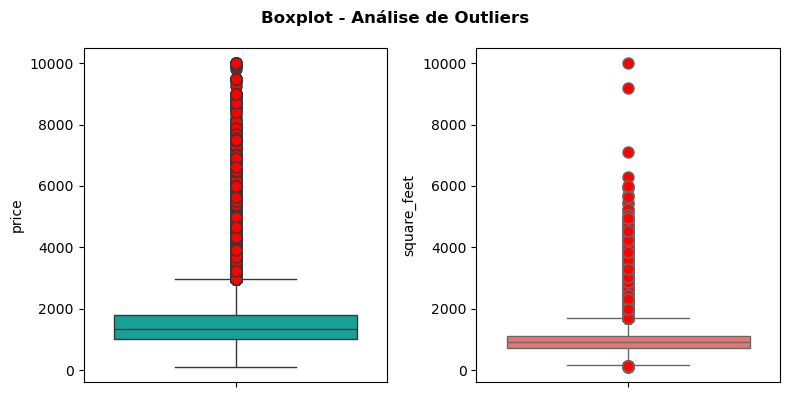

In [37]:
# Repetindo o boxplot para verificar o Aluguel e Tamanho

num_vars = ['price', 'square_feet']

plt.rcParams['figure.figsize'] = [8, 4]
plt.rcParams['figure.autolayout'] = True
COLORS = ['#01B8AA', '#FD625E']

fig, axes = plt.subplots(1, 2)
for i, (col, ax) in enumerate(zip(num_vars, axes.flatten())):
    bx = sns.boxplot(
        df_data[col], 
        color=COLORS[i % len(COLORS)], 
        flierprops={
            'marker': 'o', 
            'markersize': 8, 
            'markerfacecolor': 'red'
        },
        ax=ax
    )

fig.suptitle('Boxplot - Análise de Outliers', fontsize=12, fontweight='bold')
plt.show()

In [38]:
# Engenharia de Atributos - variável "amenities" -> Comodidade

lst = []
for i in df_data['amenities']:
    try:
        test = i.split(',')
        for w in test:
            lst.append(w)
    except:
        pass

In [39]:
# Criando um dataframe com a lista de comodidades

df_amenities = pd.DataFrame(lst, columns=['amenities'])
df_amenities.head()

,amenities
0,Parking
1,Parking
2,Parking
3,Parking
4,Parking


In [40]:
# Visualizando o agrupamento de comodidade

df_amenities.groupby(['amenities']).size().sort_values(ascending=False)

amenities
Parking               56214
Pool                  40208
Gym                   34275
Patio/Deck            24520
Washer Dryer          23711
Storage               19932
Clubhouse             17633
Dishwasher            15491
AC                    14514
Refrigerator          13960
Fireplace             13811
Cable or Satellite    11605
Playground            10377
Internet Access       10184
Wood Floors            8130
Gated                  7881
Tennis                 7799
TV                     4116
Elevator               4015
Basketball             3893
Hot Tub                3696
Garbage Disposal       3656
View                   1974
Alarm                   317
Luxury                  199
Doorman                 185
Golf                     27
dtype: int64

In [41]:
# Incluindo as variaveis em df_data
amenities_list = df_amenities['amenities'].unique()

for amenity in amenities_list:
    df_data[amenity] = df_data['amenities'] \
        .str.contains(amenity, na=False)\
        .map({True: 'Yes', False: 'No'})

In [42]:
df_data.head()

,category,amenities,bathrooms,bedrooms,fee,pets_allowed,square_feet,state,source,time,price,latitude,longitude,Parking,Fireplace,Gym,Pool,Storage,Wood Floors,Gated,Dishwasher,Clubhouse,Refrigerator,Elevator,Patio/Deck,Cable or Satellite,Garbage Disposal,Internet Access,Luxury,Playground,Basketball,Hot Tub,Tennis,Doorman,TV,Washer Dryer,View,Alarm,Golf,AC
0,housing/rent/apartment,Parking,1.0,1.0,No,Cats,542.0,CA,RentLingo,1.577360e+09,2195.0,33.8520,-118.3759,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
1,housing/rent/apartment,Parking,1.5,3.0,No,"Cats,Dogs",1500.0,VA,RentLingo,1.577360e+09,1250.0,37.0867,-76.4941,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
2,housing/rent/apartment,Parking,2.0,3.0,No,No,1650.0,NC,RentLingo,1.577360e+09,1395.0,35.8230,-78.6438,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
3,housing/rent/apartment,Parking,1.0,2.0,No,"Cats,Dogs",820.0,CA,RentLingo,1.577360e+09,1600.0,38.3622,-121.9712,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
4,housing/rent/apartment,Parking,1.0,1.0,No,"Cats,Dogs",624.0,NM,RentLingo,1.577360e+09,975.0,35.1038,-106.6110,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


In [43]:
# Engenharia de Atributos - variável "category" -> Categoria

lst = []
for cat in df_data['category']:
    try:
        category = cat.split('/')
        for w in category:
            lst.append(w)
    except:
        pass

df_category = pd.DataFrame(lst, columns=['category'])

In [44]:
category_list = df_category['category'].unique()

for cat in category_list:
    df_data[cat] = df_data['category'] \
        .str.contains(cat, na=False) \
        .map({True: 'Yes', False: 'No'})

In [45]:
df_data.head()

,category,amenities,bathrooms,bedrooms,fee,pets_allowed,square_feet,state,source,time,price,latitude,longitude,Parking,Fireplace,Gym,Pool,Storage,Wood Floors,Gated,Dishwasher,Clubhouse,Refrigerator,Elevator,Patio/Deck,Cable or Satellite,Garbage Disposal,Internet Access,Luxury,Playground,Basketball,Hot Tub,Tennis,Doorman,TV,Washer Dryer,View,Alarm,Golf,AC,housing,rent,apartment,home,short_term,condo,other,commercial,retail
0,housing/rent/apartment,Parking,1.0,1.0,No,Cats,542.0,CA,RentLingo,1.577360e+09,2195.0,33.8520,-118.3759,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No,No,No,No
1,housing/rent/apartment,Parking,1.5,3.0,No,"Cats,Dogs",1500.0,VA,RentLingo,1.577360e+09,1250.0,37.0867,-76.4941,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No,No,No,No
2,housing/rent/apartment,Parking,2.0,3.0,No,No,1650.0,NC,RentLingo,1.577360e+09,1395.0,35.8230,-78.6438,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No,No,No,No
3,housing/rent/apartment,Parking,1.0,2.0,No,"Cats,Dogs",820.0,CA,RentLingo,1.577360e+09,1600.0,38.3622,-121.9712,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No,No,No,No
4,housing/rent/apartment,Parking,1.0,1.0,No,"Cats,Dogs",624.0,NM,RentLingo,1.577360e+09,975.0,35.1038,-106.6110,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No,No,No,No


In [46]:
# Criando uma variável "time_inclusion"

from datetime import date

def convert_datetime(x):
    return date.fromtimestamp(x)
    
df_data['time_inclusion'] = df_data['time'].apply(convert_datetime)
df_data['time_inclusion'] = df_data['time_inclusion'].apply(
    lambda d: 
    pd.to_datetime(d, format='%Y/%m/%d', errors='coerce')
)

In [47]:
df_data['time_inclusion'].unique()

<DatetimeArray>
['2019-12-26 00:00:00', '2019-12-25 00:00:00', '2019-12-23 00:00:00',
 '2019-12-22 00:00:00', '2019-12-20 00:00:00', '2019-12-19 00:00:00',
 '2019-12-18 00:00:00', '2019-12-17 00:00:00', '2019-12-15 00:00:00',
 '2019-12-14 00:00:00',
 ...
 '2018-12-23 00:00:00', '2019-01-05 00:00:00', '2018-12-13 00:00:00',
 '2018-12-12 00:00:00', '2018-12-29 00:00:00', '2018-12-11 00:00:00',
 '2018-12-10 00:00:00', '2018-12-09 00:00:00', '2018-12-08 00:00:00',
 '2018-12-07 00:00:00']
Length: 329, dtype: datetime64[ns]

In [48]:
# Extraindo o ano da "Data da Inclusão"

df_data['year'] = df_data['time_inclusion'].dt.year

In [49]:
# Incluir o tempo em dias e em anos que o anuncio foi inserido

today = datetime.now()

df_data['years_announce'] = (today.year - df_data['year'])
df_data['days_announce'] = (today - df_data['time_inclusion']).dt.days

df_data.head()

,category,amenities,bathrooms,bedrooms,fee,pets_allowed,square_feet,state,source,time,price,latitude,longitude,Parking,Fireplace,Gym,Pool,Storage,Wood Floors,Gated,Dishwasher,Clubhouse,Refrigerator,Elevator,Patio/Deck,Cable or Satellite,Garbage Disposal,Internet Access,Luxury,Playground,Basketball,Hot Tub,Tennis,Doorman,TV,Washer Dryer,View,Alarm,Golf,AC,housing,rent,apartment,home,short_term,condo,other,commercial,retail,time_inclusion,year,years_announce,days_announce
0,housing/rent/apartment,Parking,1.0,1.0,No,Cats,542.0,CA,RentLingo,1.577360e+09,2195.0,33.8520,-118.3759,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No,No,No,No,2019-12-26,2019,7,2267
1,housing/rent/apartment,Parking,1.5,3.0,No,"Cats,Dogs",1500.0,VA,RentLingo,1.577360e+09,1250.0,37.0867,-76.4941,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No,No,No,No,2019-12-26,2019,7,2267
2,housing/rent/apartment,Parking,2.0,3.0,No,No,1650.0,NC,RentLingo,1.577360e+09,1395.0,35.8230,-78.6438,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No,No,No,No,2019-12-26,2019,7,2267
3,housing/rent/apartment,Parking,1.0,2.0,No,"Cats,Dogs",820.0,CA,RentLingo,1.577360e+09,1600.0,38.3622,-121.9712,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No,No,No,No,2019-12-26,2019,7,2267
4,housing/rent/apartment,Parking,1.0,1.0,No,"Cats,Dogs",624.0,NM,RentLingo,1.577360e+09,975.0,35.1038,-106.6110,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No,No,No,No,2019-12-26,2019,7,2267


In [50]:
print(f'Média de dias: {df_data.days_announce.mean()}')
print(f'Total mínimo de dias: {df_data.days_announce.min()}')
print(f'Total máximo de dias: {df_data.days_announce.max()}')

Média de dias: 2460.2756831806782
Total mínimo de dias: 2267
Total máximo de dias: 2651


In [51]:
# Tratar a variável "pets_allowed"

df_data['pets_allowed'] = df_data['pets_allowed'].replace(['Cats', 'Cats,Dogs', 'Cats,Dogs,None', 'Dogs'], 'Yes')
df_data['pets_allowed'] = df_data['pets_allowed'].replace(['None'], 'No')

In [52]:
df_data['pets_allowed'].head()

0    Yes
1    Yes
2     No
3    Yes
4    Yes
Name: pets_allowed, dtype: object

In [53]:
# Salvando o Dataframe tratado em CSV

columns = ['bathrooms', 'bedrooms', 'pets_allowed', 'square_feet', 'Gym', 'Pool', 'Parking',
          'state', 'source', 'days_announce', 'price', 'latitude', 'longitude']

df_file = pd.DataFrame(df_data, columns=columns)
df_file.to_csv('dados_tratados.csv', index=False)

In [54]:
df_file.head()

,bathrooms,bedrooms,pets_allowed,square_feet,Gym,Pool,Parking,state,source,days_announce,price,latitude,longitude
0,1.0,1.0,Yes,542.0,No,No,Yes,CA,RentLingo,2267,2195.0,33.8520,-118.3759
1,1.5,3.0,Yes,1500.0,No,No,Yes,VA,RentLingo,2267,1250.0,37.0867,-76.4941
2,2.0,3.0,No,1650.0,No,No,Yes,NC,RentLingo,2267,1395.0,35.8230,-78.6438
3,1.0,2.0,Yes,820.0,No,No,Yes,CA,RentLingo,2267,1600.0,38.3622,-121.9712
4,1.0,1.0,Yes,624.0,No,No,Yes,NM,RentLingo,2267,975.0,35.1038,-106.6110


In [55]:
# Excluir as colunas que não serão utilizadas
COLS_DROP = np.array(['category', 'amenities', 'time', 'time_inclusion', 'year', 'years_announce',
                     'latitude', 'longitude'])

df_data.drop(COLS_DROP, axis=1, inplace=True)

In [56]:
# Conferir se há ainda valores nulos

df_data.isna().sum()

bathrooms             0
bedrooms              0
fee                   0
pets_allowed          0
square_feet           0
state                 0
source                0
price                 0
Parking               0
Fireplace             0
Gym                   0
Pool                  0
Storage               0
Wood Floors           0
Gated                 0
Dishwasher            0
Clubhouse             0
Refrigerator          0
Elevator              0
Patio/Deck            0
Cable or Satellite    0
Garbage Disposal      0
Internet Access       0
Luxury                0
Playground            0
Basketball            0
Hot Tub               0
Tennis                0
Doorman               0
TV                    0
Washer Dryer          0
View                  0
Alarm                 0
Golf                  0
AC                    0
housing               0
rent                  0
apartment             0
home                  0
short_term            0
condo                 0
other           

In [57]:
df_data.shape

(92911, 45)

In [58]:
df_data.nunique()

bathrooms               13
bedrooms                11
fee                      2
pets_allowed             2
square_feet           2458
state                   51
source                  25
price                 3576
Parking                  2
Fireplace                2
Gym                      2
Pool                     2
Storage                  2
Wood Floors              2
Gated                    2
Dishwasher               2
Clubhouse                2
Refrigerator             2
Elevator                 2
Patio/Deck               2
Cable or Satellite       2
Garbage Disposal         2
Internet Access          2
Luxury                   2
Playground               2
Basketball               2
Hot Tub                  2
Tennis                   2
Doorman                  2
TV                       2
Washer Dryer             2
View                     2
Alarm                    2
Golf                     2
AC                       2
housing                  1
rent                     1
a

In [59]:
# Remover as variáveis housing - habitação e rent - aluguel, pois possuem apenas um valor

df_data.drop(['housing', 'rent'], axis=1, inplace=True)

In [60]:
df_data.reset_index(drop=True, inplace=True)

In [61]:
# Verificando a quantidade de imoveis com piscina

df_data.groupby(['Pool'], observed=False).size().sort_values(ascending=0)

Pool
No     52703
Yes    40208
dtype: int64

In [62]:
df_data.groupby(['Gym'], observed=False).size().sort_values(ascending=0)

Gym
No     58636
Yes    34275
dtype: int64

In [63]:
# Verificando quantos imoveis possuem piscina e academia juntos

qty = len(df_data.loc[
    (df_data['Pool'] == 'Yes') & 
    (df_data['Gym'] == 'Yes')
    ])
print(f'Total de imoveis com piscina e academia: {qty}')

Total de imoveis com piscina e academia: 26170


In [64]:
# Carregando as variaveis categoricas

cat_vars = [c for c in df_data.iloc[:44].columns.tolist()
           if df_data[c].dtype in ('object', 'category')]

cat_vars

['fee',
 'pets_allowed',
 'state',
 'source',
 'Parking',
 'Fireplace',
 'Gym',
 'Pool',
 'Storage',
 'Wood Floors',
 'Gated',
 'Dishwasher',
 'Clubhouse',
 'Refrigerator',
 'Elevator',
 'Patio/Deck',
 'Cable or Satellite',
 'Garbage Disposal',
 'Internet Access',
 'Luxury',
 'Playground',
 'Basketball',
 'Hot Tub',
 'Tennis',
 'Doorman',
 'TV',
 'Washer Dryer',
 'View',
 'Alarm',
 'Golf',
 'AC',
 'apartment',
 'home',
 'short_term',
 'condo',
 'other',
 'commercial',
 'retail']

In [65]:
# Realizar o OnetHotEncoder para variaveis categoricas
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('one_hot', Pipeline(steps=[
            ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
        ]), cat_vars)
    ],
    remainder='passthrough'
)

transform = ct.fit_transform(df_data)
onehot_cols = ct.named_transformers_['one_hot']['encoder'].get_feature_names_out(cat_vars)
other_cols = [c for c in df_data.columns if c not in cat_vars]

df_data = pd.DataFrame(transform, columns=list(onehot_cols) + other_cols)

In [66]:
df_data.head()

,fee_No,fee_Yes,pets_allowed_No,pets_allowed_Yes,state_AK,state_AL,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,state_GA,state_HI,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MS,state_MT,state_NC,state_ND,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,source_AgentWebsite,source_Apartable,source_BostonApartments,source_Claz,source_FreeAdsTime,source_GoSection8,source_Home Rentals,source_HousesForRent,source_Listanza,source_ListedBuy,source_Nest Seekers,source_RENTCafé,source_RENTOCULAR,source_Real Estate Agent,source_Real Estate Shows,source_RealRentals,source_RentDigs.com,source_RentFeeder,source_RentLingo,source_Seattle Rentals,source_SpreadMyAd,source_Z57,source_rentbits,source_tenantcloud,source_vFlyer,Parking_No,Parking_Yes,Fireplace_No,Fireplace_Yes,Gym_No,Gym_Yes,Pool_No,Pool_Yes,Storage_No,Storage_Yes,Wood Floors_No,Wood Floors_Yes,Gated_No,Gated_Yes,Dishwasher_No,Dishwasher_Yes,Clubhouse_No,Clubhouse_Yes,Refrigerator_No,Refrigerator_Yes,Elevator_No,Elevator_Yes,Patio/Deck_No,Patio/Deck_Yes,Cable or Satellite_No,Cable or Satellite_Yes,Garbage Disposal_No,Garbage Disposal_Yes,Internet Access_No,Internet Access_Yes,Luxury_No,Luxury_Yes,Playground_No,Playground_Yes,Basketball_No,Basketball_Yes,Hot Tub_No,Hot Tub_Yes,Tennis_No,Tennis_Yes,Doorman_No,Doorman_Yes,TV_No,TV_Yes,Washer Dryer_No,Washer Dryer_Yes,View_No,View_Yes,Alarm_No,Alarm_Yes,Golf_No,Golf_Yes,AC_No,AC_Yes,apartment_No,apartment_Yes,home_No,home_Yes,short_term_No,short_term_Yes,condo_No,condo_Yes,other_No,other_Yes,commercial_No,commercial_Yes,retail_No,retail_Yes,bathrooms,bedrooms,square_feet,price,days_announce
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,542.0,2195.0,2267.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.5,3.0,1500.0,1250.0,2267.0
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2.0,3.0,1650.0,1395.0,2267.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [67]:
df_data.shape

(92911, 153)

In [68]:
# Definir os atributos preditores e target

X = df_data.drop(['price'], axis=1).values
y = df_data['price']

In [69]:
# Dividir em treino e teste

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size=.3,
                                                   random_state=42)

X_train.shape, X_test.shape

((65037, 152), (27874, 152))

In [70]:
# Aplicandoa padronização dos dados

scaler = StandardScaler()
X_train_tf = scaler.fit_transform(X_train)
X_test_tf = scaler.transform(X_test)

### 5° - Criação, Treino e Avaliação das Métricas de Performance do Modelo

In [72]:
from collections import defaultdict

MAX_NEIGHBORS = 20
results = defaultdict(list)

for n in range(1, MAX_NEIGHBORS + 1):
    knn = KNeighborsRegressor(n_neighbors=n).fit(X_train_tf, y_train)

    for split, X, y in [('train', X_train_tf, y_train), ('test', X_test_tf, y_test)]:
        y_pred = knn.predict(X)
        results[f'mae_{split}'].append(mean_absolute_error(y, y_pred))
        results[f'mape_{split}'].append(mean_absolute_percentage_error(y, y_pred))

    diff = abs(results['mape_train'][-1] - results['mape_test'][-1])
    print(
        f'{n} | MAPE treino: {results['mape_train'][-1]:.4f} | \
        MAPE teste: {results['mape_test'][-1]:.4f} | Δ: {diff:.4f}'
    )

1 | MAPE treino: 0.0129 |         MAPE teste: 0.1747 | Δ: 0.1618
2 | MAPE treino: 0.0894 |         MAPE teste: 0.1720 | Δ: 0.0826
3 | MAPE treino: 0.1162 |         MAPE teste: 0.1752 | Δ: 0.0589
4 | MAPE treino: 0.1322 |         MAPE teste: 0.1790 | Δ: 0.0468
5 | MAPE treino: 0.1431 |         MAPE teste: 0.1824 | Δ: 0.0393
6 | MAPE treino: 0.1513 |         MAPE teste: 0.1855 | Δ: 0.0342
7 | MAPE treino: 0.1585 |         MAPE teste: 0.1884 | Δ: 0.0299
8 | MAPE treino: 0.1645 |         MAPE teste: 0.1911 | Δ: 0.0266
9 | MAPE treino: 0.1694 |         MAPE teste: 0.1931 | Δ: 0.0238
10 | MAPE treino: 0.1736 |         MAPE teste: 0.1952 | Δ: 0.0216
11 | MAPE treino: 0.1774 |         MAPE teste: 0.1972 | Δ: 0.0198
12 | MAPE treino: 0.1810 |         MAPE teste: 0.1995 | Δ: 0.0185
13 | MAPE treino: 0.1841 |         MAPE teste: 0.2012 | Δ: 0.0171
14 | MAPE treino: 0.1868 |         MAPE teste: 0.2027 | Δ: 0.0159
15 | MAPE treino: 0.1891 |         MAPE teste: 0.2040 | Δ: 0.0149
16 | MAPE treino: 0

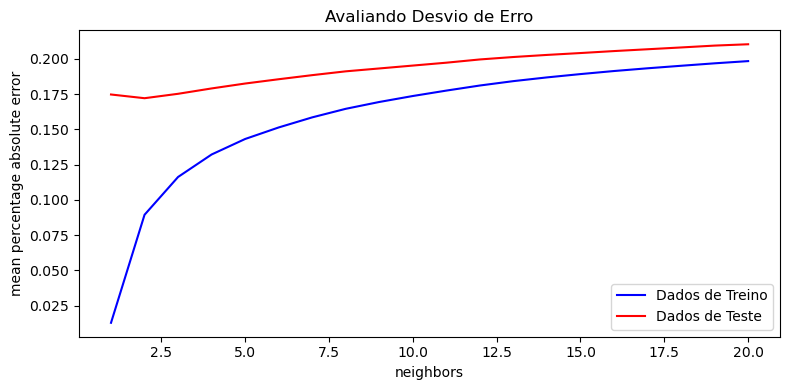

In [75]:
# Avaliando o melhor parâmetro para ajuste fino
n_neighbors = range(1, MAX_NEIGHBORS + 1)

plt.plot(n_neighbors, results["mape_train"], color='blue', label='Dados de Treino')
plt.plot(n_neighbors, results["mape_test"], color='red', label='Dados de Teste')
plt.title('Avaliando Desvio de Erro')
plt.legend(loc='lower right')
plt.xlabel('neighbors')
plt.ylabel('mean percentage absolute error')
plt.show()

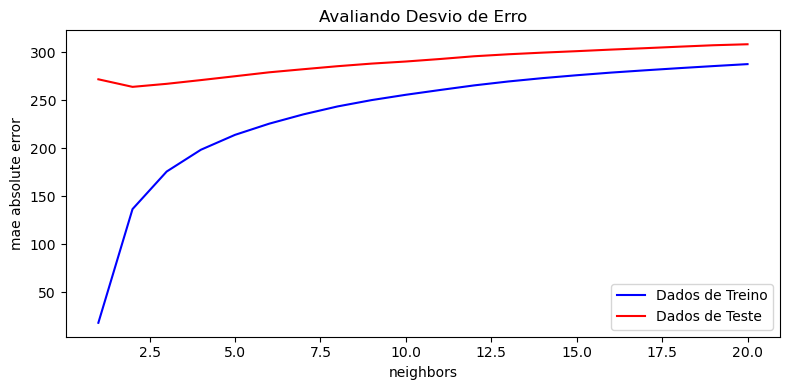

In [76]:
# Avaliando o melhor parâmetro para ajuste fino

n_neighbors = range(1, MAX_NEIGHBORS + 1)

plt.plot(n_neighbors, results["mae_train"], color='blue', label='Dados de Treino')
plt.plot(n_neighbors, results["mae_test"], color='red', label='Dados de Teste')
plt.title('Avaliando Desvio de Erro')
plt.legend(loc='lower right')
plt.xlabel('neighbors')
plt.ylabel('mae absolute error')
plt.show()

In [77]:
# Construir o modelo com k=10, pois os erros de treino e teste estão bem próximos

knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_tf, y_train)

KNeighborsRegressor(n_neighbors=10)

In [78]:
# Previsão e Acurácia - Treino
y_pred_train = knn.predict(X_train_tf)
print('MAE: ', mean_absolute_error(y_pred_train, y_train))
print('MAPE ', mean_absolute_percentage_error(y_pred_train, y_train))

MAE:  255.58764069683414
MAPE  0.16197830939379007


In [79]:
# Previsão e Acurácia - Teste
y_pred_test  = knn.predict(X_test_tf)
print('MAE: ', mean_absolute_error(y_pred_test, y_test))
print('MAPE: ', mean_absolute_percentage_error(y_pred_test, y_test))

MAE:  290.24531463012124
MAPE:  0.1855716782295684


In [80]:
# Avaliando se a margem de erro é "Alto" ou "Baixo"

pd.options.display.float_format = '{:.2f}'.format
df_eval = pd.DataFrame()
df_eval['Aluguel_Real'] = y_test
df_eval['Aluguel_Previsto'] = y_pred_test
df_eval.reset_index(drop=True, inplace=True)
df_eval.head()

,Aluguel_Real,Aluguel_Previsto
0,1175.00,1707.00
1,1315.00,1043.40
2,4654.00,4719.80
3,3390.00,3417.30
4,649.00,1080.10


In [81]:
# Pegando o valor médio real do aluguel
df_eval['Aluguel_Real'].mean()

1519.167934275669

In [82]:
# Calculando o erro do modelo

df_eval['Erro'] = df_eval['Aluguel_Real'] - df_eval['Aluguel_Previsto']
df_eval.head(10)

,Aluguel_Real,Aluguel_Previsto,Erro
0,1175.00,1707.00,-532.00
1,1315.00,1043.40,271.60
2,4654.00,4719.80,-65.80
3,3390.00,3417.30,-27.30
4,649.00,1080.10,-431.10
5,1095.00,1524.50,-429.50
6,2225.00,2198.50,26.50
7,2659.00,2350.40,308.60
8,1888.00,1094.90,793.10
9,3430.00,1735.60,1694.40


In [83]:
df_eval['Erro_abs'] = np.abs(df_eval['Erro'])
df_eval.head()

,Aluguel_Real,Aluguel_Previsto,Erro,Erro_abs
0,1175.00,1707.00,-532.00,532.00
1,1315.00,1043.40,271.60,271.60
2,4654.00,4719.80,-65.80,65.80
3,3390.00,3417.30,-27.30,27.30
4,649.00,1080.10,-431.10,431.10


In [84]:
# Encontrando o percentual de erro para cada observação (Real x Previsto)

df_eval['percentual_erro'] = ((df_eval['Aluguel_Real'] - df_eval['Aluguel_Previsto']) / df_eval['Aluguel_Real'])
df_eval.head()

,Aluguel_Real,Aluguel_Previsto,Erro,Erro_abs,percentual_erro
0,1175.00,1707.00,-532.00,532.00,-0.45
1,1315.00,1043.40,271.60,271.60,0.21
2,4654.00,4719.80,-65.80,65.80,-0.01
3,3390.00,3417.30,-27.30,27.30,-0.01
4,649.00,1080.10,-431.10,431.10,-0.66


In [85]:
# Adaptando como valor absoluto

df_eval['percentual_erro_abs'] = np.abs(df_eval['percentual_erro'])
df_eval.head()

,Aluguel_Real,Aluguel_Previsto,Erro,Erro_abs,percentual_erro,percentual_erro_abs
0,1175.00,1707.00,-532.00,532.00,-0.45,0.45
1,1315.00,1043.40,271.60,271.60,0.21,0.21
2,4654.00,4719.80,-65.80,65.80,-0.01,0.01
3,3390.00,3417.30,-27.30,27.30,-0.01,0.01
4,649.00,1080.10,-431.10,431.10,-0.66,0.66


In [86]:
# Visualizando o percentual arrendodado - MAPE

print('MAPE: ', round(np.mean(df_eval['percentual_erro_abs']) * 100,0))

MAPE:  20.0
